In [1]:
import numpy as np
import pandas as pd
import sklearn
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path


#Task 1 : Data preparation

In [2]:
interactions = pd.read_csv(Path.cwd().parent/"data"/"interactions_train.csv")
items = pd.read_csv(Path.cwd().parent/"data"/"items.csv")
sample = pd.read_csv(Path.cwd().parent/"data"/"sample_submission.csv")

display(interactions.head())
display(items.head())
display(sample.head())

,u,i,t
0,4456,8581,1.687541e+09
1,142,1964,1.679585e+09
2,362,3705,1.706872e+09
3,1809,11317,1.673533e+09
4,4384,1323,1.681402e+09


,Title,Author,ISBN Valid,Publisher,Subjects,i
0,Classification décimale universelle : édition ...,NaN,9782871303336; 2871303339,Ed du CEFAL,Classification décimale universelle; Indexatio...,0
1,Les interactions dans l'enseignement des langu...,"Cicurel, Francine, 1947-",9782278058327; 2278058320,Didier,didactique--langue étrangère - enseignement; d...,1
2,Histoire de vie et recherche biographique : pe...,NaN,2343190194; 9782343190198,L'Harmattan,Histoires de vie en sociologie; Sciences socia...,2
3,Ce livre devrait me permettre de résoudre le c...,"Mazas, Sylvain, 1980-",9782365350020; 236535002X; 9782365350488; 2365...,Vraoum!,Moyen-Orient; Bandes dessinées autobiographiqu...,3
4,Les années glorieuses : roman /,"Lemaitre, Pierre, 1951-",9782702180815; 2702180817; 9782702183618; 2702...,Calmann-Lévy,France--1945-1975; Roman historique; Roman fra...,4


,user_id,recommendation
0,0,3758 11248 9088 9895 5101 6074 9295 14050 1096...
1,1,3263 726 1589 14911 6432 10897 6484 7961 8249 ...
2,2,13508 9848 12244 2742 11120 2893 2461 5439 116...
3,3,2821 10734 6357 5934 2085 12608 12539 10551 10...
4,4,12425 219 11602 1487 14178 489 13888 2110 4413...


In [3]:
num_unique_users = interactions['u'].nunique()
num_unique_items = interactions['i'].nunique()
num_interactions = interactions.shape[0]


print(f"Number of unique users: {num_unique_users}")
print(f"Number of unique items: {num_unique_items}")
print(f"Number of interactions: {num_interactions}")

Number of unique users: 7838
Number of unique items: 15109
Number of interactions: 87047


Split the data into training (80%) and test(20%) sets






In [4]:
# let's first sort the interactions by user and time stamp
interactions = interactions.sort_values(["u", "t"])
interactions.head(10)

,u,i,t
21035,0,0,1.680191e+09
28842,0,1,1.680783e+09
3958,0,2,1.680801e+09
29592,0,3,1.683715e+09
6371,0,3,1.683715e+09
41220,0,4,1.686569e+09
12217,0,5,1.687014e+09
19703,0,6,1.687014e+09
64522,0,7,1.687014e+09
29380,0,8,1.687260e+09


Percentage rank

In [5]:
interactions["pct_rank"] = interactions.groupby("u")["t"].rank(pct=True, method='dense')
interactions.reset_index(inplace=True, drop=True)
interactions.head(10)

,u,i,t,pct_rank
0,0,0,1.680191e+09,0.04
1,0,1,1.680783e+09,0.08
2,0,2,1.680801e+09,0.12
3,0,3,1.683715e+09,0.16
4,0,3,1.683715e+09,0.20
5,0,4,1.686569e+09,0.24
6,0,5,1.687014e+09,0.28
7,0,6,1.687014e+09,0.32
8,0,7,1.687014e+09,0.36
9,0,8,1.687260e+09,0.40


In [6]:
train_data = interactions[interactions["pct_rank"] < 0.8]
test_data = interactions[interactions["pct_rank"] >= 0.8]

print("Training set size:", train_data.shape[0])
print("Testing set size:", test_data.shape[0])

Training set size: 65419
Testing set size: 21628


#Task 2: Creating User-Item Matrices for Implicit Feedback

In [7]:
print('number of users =', num_unique_users, '| number of books =', num_unique_items)

number of users = 7838 | number of books = 15109


Create the data matrix
(1 if there was an interaction and a 0 otherwise)

In [7]:
def create_data_matrix(data, n_users, n_items):
    """
    This function returns a numpy matrix with shape (n_users, n_items).
    Each entry is a binary value indicating positive interaction.
    """
    data_matrix = np.zeros((n_users, n_items))
    data_matrix[data["u"].values, data["i"].values] = 1
    return data_matrix

Create the training and test matrix


In [8]:
# Create the training and testing matrices

# Calculate the correct number of items (maximum item ID + 1)
# This is necessary because item IDs might not be contiguous or start from 0
# and num_unique_items only counts distinct values, not the max value.
max_item_id = interactions['i'].max()
actual_num_items = max_item_id + 1

train_data_matrix = create_data_matrix(train_data, num_unique_users, actual_num_items)
test_data_matrix = create_data_matrix(test_data, num_unique_users, actual_num_items)

# Display the matrices to understand their structure
print('train_data_matrix')
print(train_data_matrix)
print("number of non-zero values: ", np.sum(train_data_matrix))
print('test_data_matrix')
print(test_data_matrix)
print("number of non-zero values: ", np.sum(test_data_matrix))

train_data_matrix
[[1. 1. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
number of non-zero values:  49689.0
test_data_matrix
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
number of non-zero values:  19409.0


Visualize the User-Item Interaction Matrices

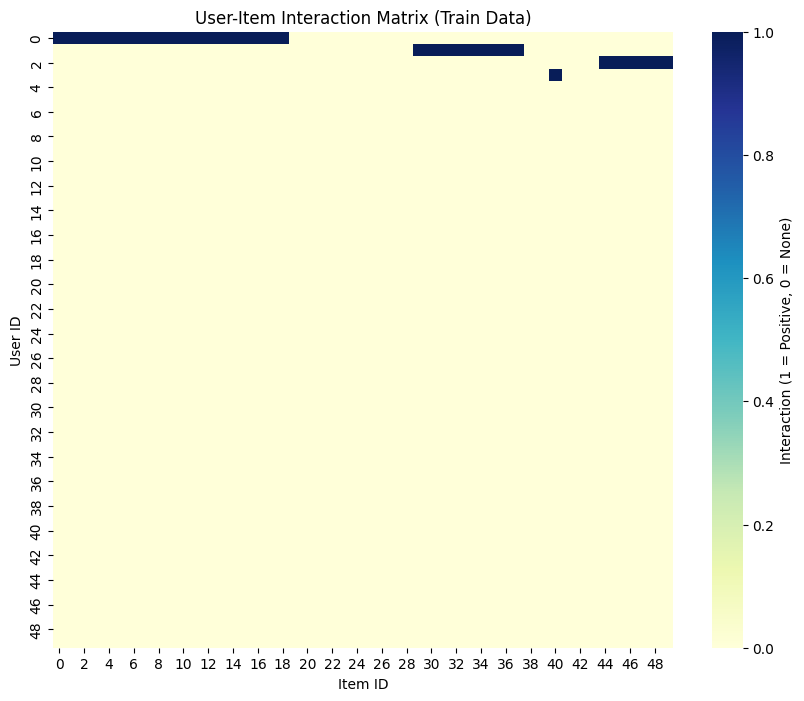

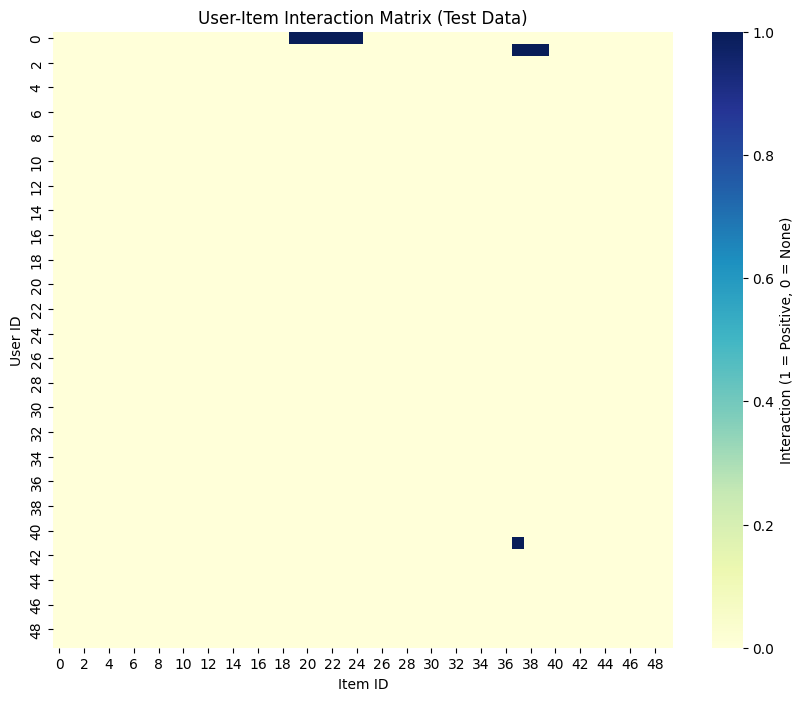

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot a heatmap for a subset of the user-item matrix
def plot_interaction_heatmap(data_matrix, title, num_users=50, num_items=50):
    """
    Plots a heatmap of a subset of the user-item interaction matrix.
    Parameters:
        data_matrix: The matrix to visualize.
        title: The title of the plot.
        num_users: The number of users to display (rows).
        num_items: The number of items to display (columns).
    """
    # Extract a subset of the matrix for visualization purposes
    matrix_subset = data_matrix[:num_users, :num_items]

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_subset, cmap="YlGnBu", cbar=True, cbar_kws={'label': 'Interaction (1 = Positive, 0 = None)'})
    plt.xlabel('Item ID')
    plt.ylabel('User ID')
    plt.title(title)
    plt.show()

# Visualize a subset of the training and testing matrices
plot_interaction_heatmap(train_data_matrix, 'User-Item Interaction Matrix (Train Data)')
plot_interaction_heatmap(test_data_matrix, 'User-Item Interaction Matrix (Test Data)')

#Task 3: Item-to-Item Collaborative Filtering with Implicit Feedback


Item Similarity matrix

In [9]:
# As the cosine_similarity function computes similarity between rows, we need to transpose
# the train_data_matrix to become items as rows and users as columns.
item_similarity = cosine_similarity(train_data_matrix.T)
print("Item-Item Similarity Matrix:")
print(item_similarity)
print(item_similarity.shape)

Item-Item Similarity Matrix:
[[1.         0.40824829 0.33333333 ... 0.         0.         0.        ]
 [0.40824829 1.         0.40824829 ... 0.         0.         0.        ]
 [0.33333333 0.40824829 1.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 1.         0.         0.        ]
 [0.         0.         0.         ... 0.         1.         0.        ]
 [0.         0.         0.         ... 0.         0.         1.        ]]
(15291, 15291)


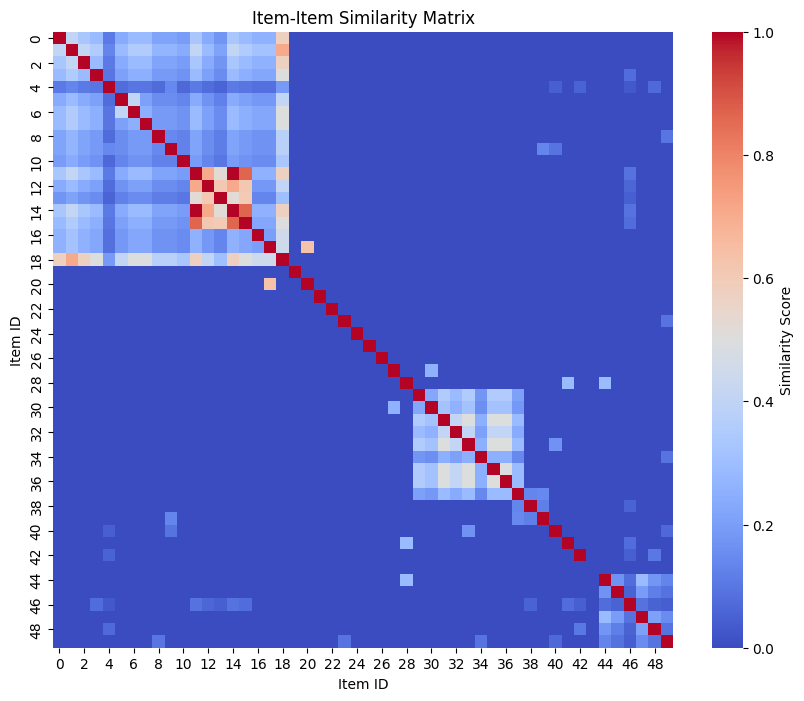

In [12]:
# Function to visualize the item similarity matrix
def plot_item_similarity_heatmap(similarity_matrix, title, num_items=50):
    """
    Plots a heatmap of a subset of the item similarity matrix.
    Parameters:
        similarity_matrix: The item-item similarity matrix.
        title: The title of the plot.
        num_items: The number of items to display (both rows and columns).
    """
    # Extract a subset of the matrix for visualization
    matrix_subset = similarity_matrix[:num_items, :num_items]

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_subset, cmap="coolwarm", cbar=True, cbar_kws={'label': 'Similarity Score'})
    plt.xlabel('Item ID')
    plt.ylabel('Item ID')
    plt.title(title)
    plt.show()

# Visualize a subset of the item similarity matrix
plot_item_similarity_heatmap(item_similarity, 'Item-Item Similarity Matrix')


Predict Positive Interactions Using Item Similarity

Item-to-item recommendation.

The result is a prediction matrix where each cell indicates the predicted likelihood of an interaction between each user and item.

In [10]:
# Define the function to predict interactions based on item similarity
def item_based_predict(interactions, similarity, epsilon=1e-9):
    """
    Predicts user-item interactions based on item-item similarity.
    Parameters:
        interactions (numpy array): The user-item interaction matrix.
        similarity (numpy array): The item-item similarity matrix.
        epsilon (float): Small constant added to the denominator to avoid division by zero.
    Returns:
        numpy array: The predicted interaction scores for each user-item pair.
    """
    # np.dot does the matrix multiplication. Here we are calculating the
    # weighted sum of interactions based on item similarity
    pred = similarity.dot(interactions.T) / (similarity.sum(axis=1)[:, np.newaxis] + epsilon)
    return pred.T  # Transpose to get users as rows and items as columns

# Calculate the item-based predictions for positive interactions
item_prediction = item_based_predict(train_data_matrix, item_similarity)
print("Predicted Interaction Matrix:")
print(item_prediction)
print(item_prediction.shape)

Predicted Interaction Matrix:
[[0.46097255 0.85435984 0.71867834 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
(7838, 15291)


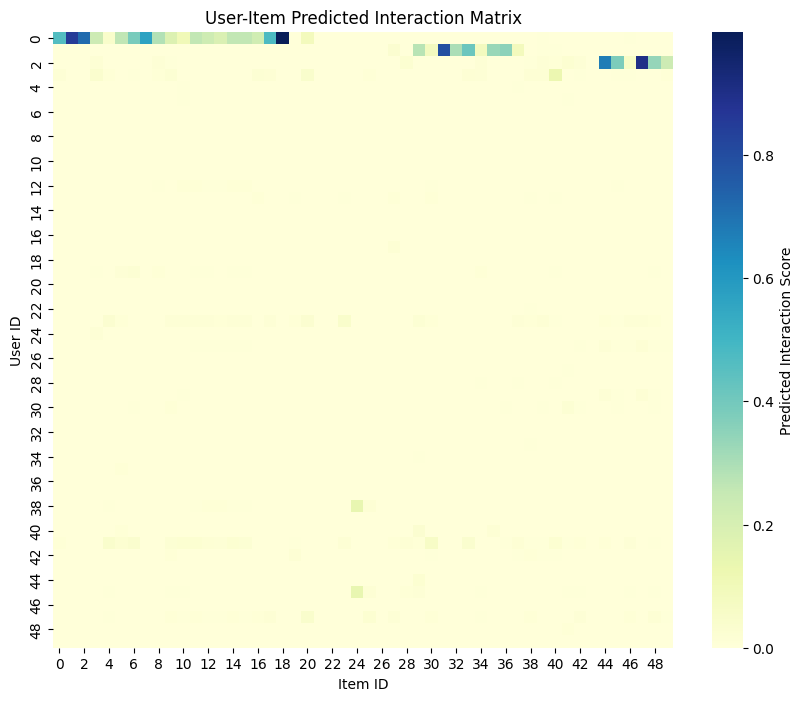

In [14]:
# Function to visualize the predicted interaction matrix for a subset of users and items
def plot_interaction_prediction_heatmap(prediction_matrix, title, num_users=50, num_items=50):
    """
    Plots a heatmap of a subset of the user-item predicted interaction matrix.
    Parameters:
        prediction_matrix: The predicted interaction matrix.
        title: The title of the plot.
        num_users: The number of users to display (rows).
        num_items: The number of items to display (columns).
    """
    # Extract a subset of the matrix for visualization
    matrix_subset = prediction_matrix[:num_users, :num_items]

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_subset, cmap="YlGnBu", cbar=True, cbar_kws={'label': 'Predicted Interaction Score'})
    plt.xlabel('Item ID')
    plt.ylabel('User ID')
    plt.title(title)
    plt.show()

# Visualize a subset of the predicted interaction matrix
plot_interaction_prediction_heatmap(item_prediction, 'User-Item Predicted Interaction Matrix')


User Similarity Matrix

In [11]:
# Compute the user-user similarity matrix
user_similarity = cosine_similarity(train_data_matrix)
print("User-User Similarity Matrix:")
print(user_similarity)


print("Shape of User Similarity Matrix:", user_similarity.shape)


User-User Similarity Matrix:
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
Shape of User Similarity Matrix: (7838, 7838)


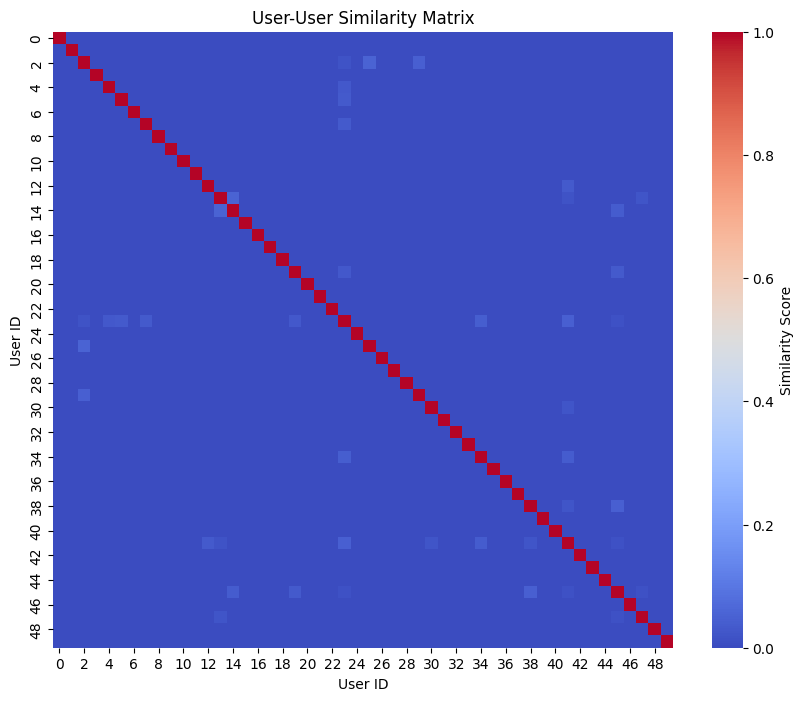

In [16]:
# Function to plot the user similarity matrix
def plot_user_similarity_heatmap(similarity_matrix, title, num_users=50):
    """
    Plots a heatmap of a subset of the user similarity matrix.
    Parameters:
        similarity_matrix: The user-user similarity matrix.
        title: The title of the plot.
        num_users: The number of users to display (both rows and columns).
    """
    # Extract a subset of the matrix for visualization
    matrix_subset = similarity_matrix[:num_users, :num_users]

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_subset, cmap="coolwarm", cbar=True, cbar_kws={'label': 'Similarity Score'})
    plt.xlabel('User ID')
    plt.ylabel('User ID')
    plt.title(title)
    plt.show()

# Visualize a subset of the user similarity matrix
plot_user_similarity_heatmap(user_similarity, 'User-User Similarity Matrix')


Predict positive interactions using user similarity

In [12]:
# Define the function to predict interactions based on user similarity
def user_based_predict(interactions, similarity, epsilon=1e-9):
    """
    Predicts user-item interactions based on user-user similarity.
    Parameters:
        interactions (numpy array): The user-item interaction matrix.
        similarity (numpy array): The user-user similarity matrix.
        epsilon (float): Small constant added to the denominator to avoid division by zero.
    Returns:
        numpy array: The predicted interaction scores for each user-item pair.
    """
    # Calculate the weighted sum of interactions based on user similarity
    pred = similarity.dot(interactions) / (np.abs(similarity).sum(axis=1)[:, np.newaxis] + epsilon)
    return pred

# Calculate the user-based predictions for positive interactions
user_prediction = user_based_predict(train_data_matrix, user_similarity)
print("Predicted Interaction Matrix (User-Based):")
print(user_prediction)
print(user_prediction.shape)


Predicted Interaction Matrix (User-Based):
[[0.13171649 0.13259591 0.14274867 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
(7838, 15291)


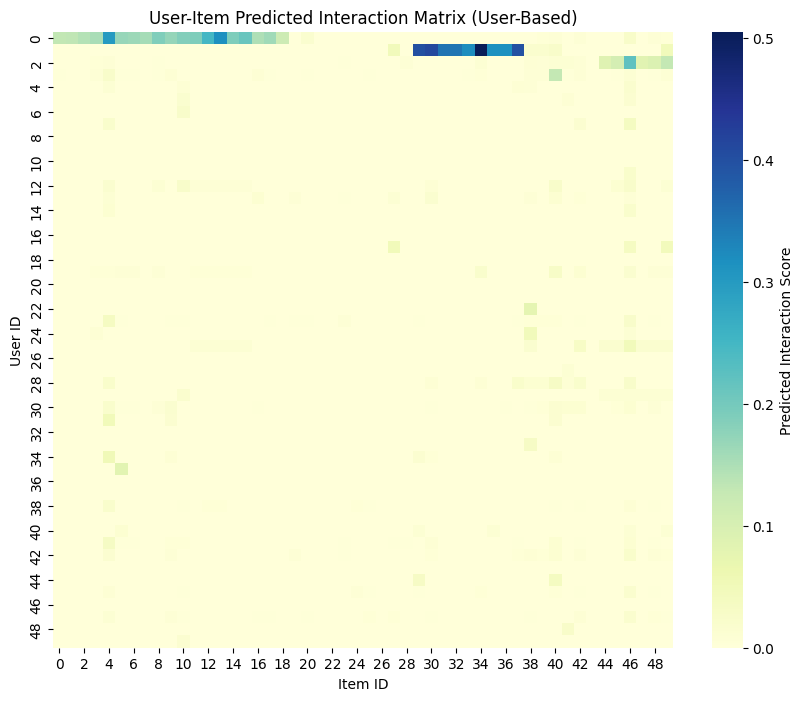

In [18]:
# Function to visualize the predicted interaction matrix for a subset of users and items
def plot_interaction_prediction_heatmap(prediction_matrix, title, num_users=50, num_items=50):
    """
    Plots a heatmap of a subset of the user-item predicted interaction matrix.
    Parameters:
        prediction_matrix: The predicted interaction matrix.
        title: The title of the plot.
        num_users: The number of users to display (rows).
        num_items: The number of items to display (columns).
    """
    # Extract a subset of the matrix for visualization
    matrix_subset = prediction_matrix[:num_users, :num_items]

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_subset, cmap="YlGnBu", cbar=True, cbar_kws={'label': 'Predicted Interaction Score'})
    plt.xlabel('Item ID')
    plt.ylabel('User ID')
    plt.title(title)
    plt.show()

# Visualize a subset of the predicted interaction matrix
plot_interaction_prediction_heatmap(user_prediction, 'User-Item Predicted Interaction Matrix (User-Based)')


#Task 5: Evaluating the Recommenders

Ranking Accuracy (Precision@K and Recall@K)

In [19]:
import numpy as np

# TODO: Implement the precision_recall_at_k function
def precision_recall_at_k(prediction, ground_truth, k=10):
    """
    Calculates Precision@K and Recall@K for top-K recommendations.
    Parameters:
        prediction (numpy array): The predicted interaction matrix with scores.
        ground_truth (numpy array): The ground truth interaction matrix (binary).
        k (int): Number of top recommendations to consider.
    Returns:
        precision_at_k (float): The average precision@K over all users.
        recall_at_k (float): The average recall@K over all users.
    """
    num_users = prediction.shape[0]
    precision_at_k, recall_at_k = 0, 0

    for user in range(num_users):
        # TODO: Get the indices of the top-K items for the user based on predicted scores
        top_k_items = np.argsort(prediction[user, :])[-k:]

        # TODO: Calculate the number of relevant items in the top-K items for the user
        relevant_items_in_top_k = np.isin(top_k_items, np.where(ground_truth[user, :] == 1)[0]).sum()

        # TODO: Calculate the total number of relevant items for the user
        total_relevant_items = ground_truth[user, :].sum()

        # Precision@K and Recall@K for this user
        precision_at_k += relevant_items_in_top_k / k
        recall_at_k += relevant_items_in_top_k / total_relevant_items if total_relevant_items > 0 else 0

    # Average Precision@K and Recall@K over all users
    precision_at_k /= num_users
    recall_at_k /= num_users

    return precision_at_k, recall_at_k


In [13]:
user_prediction.shape, item_prediction.shape

((7838, 15291), (7838, 15291))

In [20]:

precision_user_k, recall_user_k = precision_recall_at_k(user_prediction, test_data_matrix, k=10)
precision_item_k, recall_item_k = precision_recall_at_k(item_prediction, test_data_matrix, k=10)

print('User-based CF Precision@K:', precision_user_k)
print('User-based CF Recall@K:', recall_user_k)
print('Item-based CF Precision@K:', precision_item_k)
print('Item-based CF Recall@K:', recall_item_k)


User-based CF Precision@K: 0.05651952028578994
User-based CF Recall@K: 0.2904556034557242
Item-based CF Precision@K: 0.05572850216892345
Item-based CF Recall@K: 0.26418648020233576


#Task 6: Show the Recommendations for a Specific User

Select a user and get recommendations

In [21]:
import random

# Pick a user at random
user_id = random.choice(range(user_prediction.shape[0]))
print("Selected User ID:", user_id)

# Get top-10 recommendations for the user from User-to-User CF
user_top_10 = np.argsort(user_prediction[user_id, :])[-10:][::-1]

# Get top-10 recommendations for the user from Item-to-Item CF
item_top_10 = np.argsort(item_prediction[user_id, :])[-10:][::-1]

# Display top-10 recommended movie IDs for both models
display(user_top_10)
display(item_top_10)

Selected User ID: 2270


array([ 9393, 11358,  6761,  4971,  9239, 12207, 11359,  5243,  9392,
        8291])

array([11359,  9239,  8291,  1124,  6761, 11358, 12207,  9292,  8647,
        4971])

Create recommendation DF

In [22]:
items_df = items.copy()
items_df = items_df.rename(columns={'id': 'i'})

# Prepare User-based recommendations DataFrame
user_recs_df = pd.DataFrame({
    'rank': range(1, len(user_top_10) + 1),
    'i': user_top_10
})
user_recs_df = pd.merge(user_recs_df, items_df[['i', 'Title', 'Author']], on='i', how='left')

print(f"User-based recommendations for user {user_id}:")
display(user_recs_df)

# Prepare Item-based recommendations DataFrame
item_recs_df = pd.DataFrame({
    'rank': range(1, len(item_top_10) + 1),
    'i': item_top_10
})
item_recs_df = pd.merge(item_recs_df, items_df[['i', 'Title', 'Author']], on='i', how='left')

print(f"\nItem-based recommendations for user {user_id}:")
display(item_recs_df)

User-based recommendations for user 2270:


,rank,i,Title,Author
0,1,9393,L'imaginaire du sabbat : édition critique des ...,NaN
1,2,11358,Le diable chez l'évêque : chasse aux sorciers ...,"Modestin, Georg, 1969-"
2,3,6761,Inquisition et sorcellerie en Suisse romande :...,NaN
3,4,4971,"""Folâtrer avec les démons"" : sabbat et chasse ...","Ostorero, Martine"
4,5,9239,Le sabbat des sorcières /,"Ginzburg, Carlo"
5,6,12207,"Justice et criminalité : Vaud, XVe-XXIe siècles /",NaN
6,7,11359,La sorcellerie comme exutoire : tensions et co...,"Choffat, Pierre-Han"
7,8,5243,Les sorciers à l'assaut du village : Gollion (...,"Taric, Fabienne"
8,9,9392,Procès de sorcellerie dans la vallée de Conc...,"Ammann-Doubliez, Chantal, 1956-"
9,10,8291,Les dignitaires de l'église Notre-Dame de Laus...,"Reymond, Maxime, 1872-1951"



Item-based recommendations for user 2270:


,rank,i,Title,Author
0,1,11359,La sorcellerie comme exutoire : tensions et co...,"Choffat, Pierre-Han"
1,2,9239,Le sabbat des sorcières /,"Ginzburg, Carlo"
2,3,8291,Les dignitaires de l'église Notre-Dame de Laus...,"Reymond, Maxime, 1872-1951"
3,4,1124,Le sabbat des sorcières /,"Ginzburg, Carlo"
4,5,6761,Inquisition et sorcellerie en Suisse romande :...,NaN
5,6,11358,Le diable chez l'évêque : chasse aux sorciers ...,"Modestin, Georg, 1969-"
6,7,12207,"Justice et criminalité : Vaud, XVe-XXIe siècles /",NaN
7,8,9292,"L'ombre du diable : Michée Chauderon, dernière...","Porret, Michel, 1955-"
8,9,8647,Averroès l'inquiétant /,"Brenet, Jean-Baptiste"
9,10,4971,"""Folâtrer avec les démons"" : sabbat et chasse ...","Ostorero, Martine"


Build submission

In [23]:
submission_user = pd.DataFrame()
submission_user["user_id"] = sample["user_id"]
submission_item = submission_user.copy()
predictions_user = []
precision_item = []
for u in submission_user["user_id"]:
    top_10_items = np.argsort(user_prediction[u, :])[-10:][::-1]
    top_10_users = np.argsort(item_prediction[u, :])[-10:][::-1]
    predictions_user.append(" ".join(map(str, top_10_users)))
    precision_item.append(" ".join(map(str, top_10_items)))
submission_user["recommendation"] = predictions_user
submission_item["recommendation"] = precision_item
submission_user.to_csv(Path.cwd().parent/"submissions"/"submission_user_baseline_AD.csv", index=False)
submission_item.to_csv(Path.cwd().parent/"submissions"/"submission_item_baseline_AD.csv", index=False)

In [25]:
full_data_mtx = create_data_matrix(interactions, num_unique_users, actual_num_items)
print("Number of interactions in full set:", np.sum(full_data_mtx))

# 2. Recompute Item-Item similarities and predictions on the full dataset
print("Computing full Item-based predictions...")
full_item_similarity = cosine_similarity(full_data_mtx.T)
full_item_prediction = item_based_predict(full_data_mtx, full_item_similarity)

# 3. Recompute User-User similarities and predictions on the full dataset
print("Computing full User-based predictions...")
full_user_similarity = cosine_similarity(full_data_mtx)
full_user_prediction = user_based_predict(full_data_mtx, full_user_similarity)

# 4. Build the final submission using the completely retrained predictions
sample_submission = pd.read_csv(Path.cwd().parent/"data"/"sample_submission.csv")

submission_user = pd.DataFrame()
submission_user["user_id"] = sample_submission["user_id"]

submission_item = pd.DataFrame()
submission_item["user_id"] = sample_submission["user_id"]

predictions_user = []
predictions_item = []

for u in submission_user["user_id"]:
    top_10_items = np.argsort(full_item_prediction[u, :])[-10:][::-1]
    top_10_users = np.argsort(full_user_prediction[u, :])[-10:][::-1]
    predictions_user.append(" ".join(map(str, top_10_users)))
    predictions_item.append(" ".join(map(str, top_10_items)))
submission_user["recommendation"] = predictions_user
submission_item["recommendation"] = predictions_item
submission_user.to_csv(Path.cwd().parent/"submissions"/"submission_user_baseline_AD_full_retrained.csv", index=False)
submission_item.to_csv(Path.cwd().parent/"submissions"/"submission_item_baseline_AD_full_retrained.csv", index=False)

Number of interactions in full set: 64003.0
Computing full Item-based predictions...
Computing full User-based predictions...


In [ ]:
len(precision_item)

23514

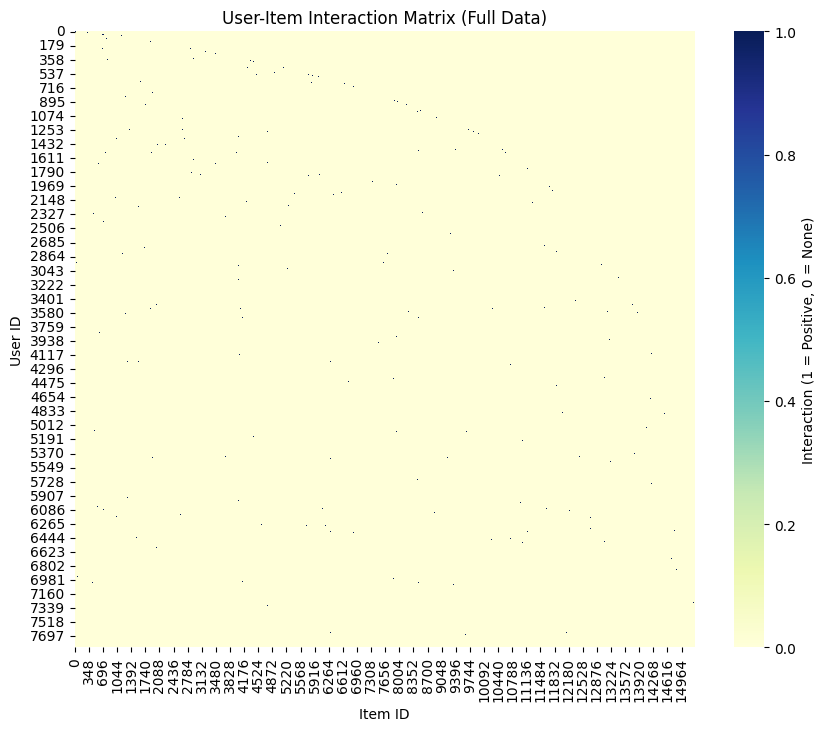

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_interaction_heatmap(data_matrix, title):
    """
    Plots a heatmap of a subset of the user-item interaction matrix.
    Parameters:
        data_matrix: The matrix to visualize.
        title: The title of the plot.
        num_users: The number of users to display (rows).
        num_items: The number of items to display (columns).
    """
    # Extract a subset of the matrix for visualization purposes
    matrix_subset = data_matrix[:, :]

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_subset, cmap="YlGnBu", cbar=True, cbar_kws={'label': 'Interaction (1 = Positive, 0 = None)'})
    plt.xlabel('Item ID')
    plt.ylabel('User ID')
    plt.title(title)
    plt.show()

def create_data_matrix(data, n_users, n_items):
    """
    This function returns a numpy matrix with shape (n_users, n_items).
    Each entry is a binary value indicating positive interaction.
    """
    data_matrix = np.zeros((n_users, n_items))
    data_matrix[data["u"].values, data["i"].values] = 1
    return data_matrix

max_item_id = interactions['i'].max()
actual_num_items = max_item_id + 1

full_data_mtx = create_data_matrix(interactions, num_unique_users, actual_num_items)
plot_interaction_heatmap(full_data_mtx, 'User-Item Interaction Matrix (Full Data)')

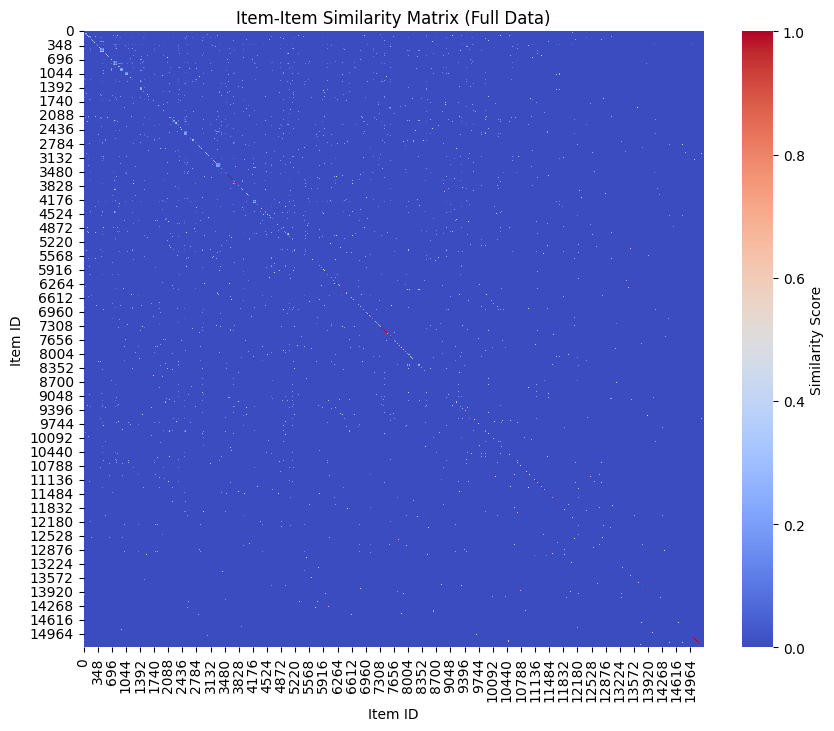

In [9]:
def plot_item_similarity_heatmap(similarity_matrix, title):
    """
    Plots a heatmap of a subset of the item similarity matrix.
    Parameters:
        similarity_matrix: The item-item similarity matrix.
        title: The title of the plot.
        num_items: The number of items to display (both rows and columns).
    """
    # Extract a subset of the matrix for visualization
    matrix_subset = similarity_matrix[:, :]

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_subset, cmap="coolwarm", cbar=True, cbar_kws={'label': 'Similarity Score'})
    plt.xlabel('Item ID')
    plt.ylabel('Item ID')
    plt.title(title)
    plt.show()

# Visualize a subset of the item similarity matrix
full_item_similarity = cosine_similarity(full_data_mtx.T)
plot_item_similarity_heatmap(full_item_similarity, 'Item-Item Similarity Matrix (Full Data)')

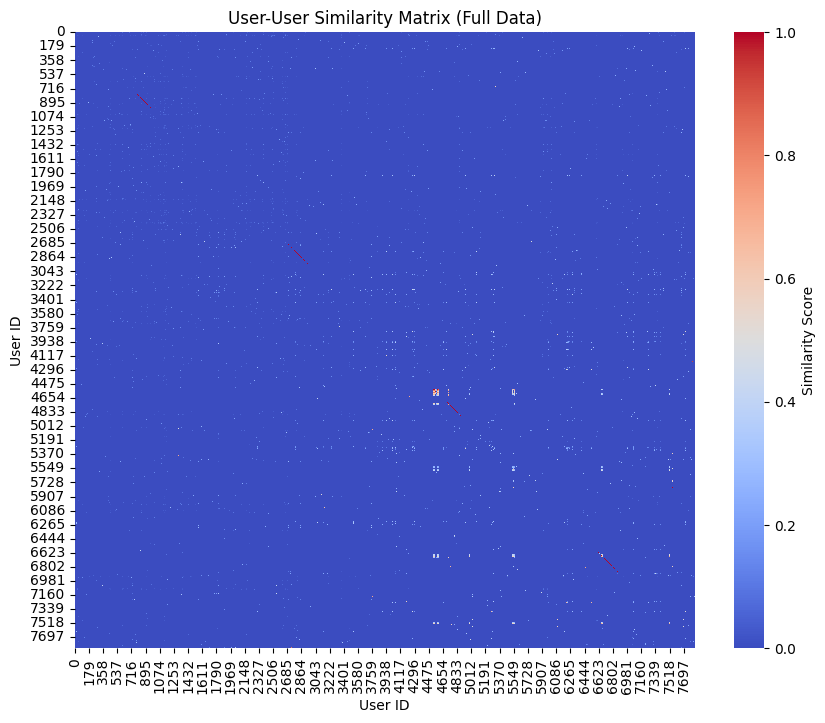

In [11]:
# Function to plot the user similarity matrix
def plot_user_similarity_heatmap(similarity_matrix, title):
    """
    Plots a heatmap of a subset of the user similarity matrix.
    Parameters:
        similarity_matrix: The user-user similarity matrix.
        title: The title of the plot.
        num_users: The number of users to display (both rows and columns).
    """
    # Extract a subset of the matrix for visualization
    matrix_subset = similarity_matrix[:, :]

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_subset, cmap="coolwarm", cbar=True, cbar_kws={'label': 'Similarity Score'})
    plt.xlabel('User ID')
    plt.ylabel('User ID')
    plt.title(title)
    plt.show()

# Visualize a subset of the user similarity matrix
full_user_similarity = cosine_similarity(full_data_mtx)
plot_user_similarity_heatmap(full_user_similarity, 'User-User Similarity Matrix (Full Data)')